# Machine Learning models for CO2 emission forecast

Machine learning frameworks for forecasting CO2 emission per capita in units of Tonnes per person


# Connect and authorize google drive

In [1]:
# from google.colab import drive
# drive.mount('/content/gdrive')
# !ls

In [3]:
! pwd

/content


# Install packages

In [4]:
# ! pip install spectral_cube

# Libraries

In [5]:

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

import numpy as np
import pandas as pd
import scipy as sp
import requests
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA

from astropy.io          import fits
from astropy             import units as u
from astropy.coordinates import SkyCoord
from astropy.wcs         import WCS

import h5py
import pickle
import time


from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

import statsmodels
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint, adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

from sklearn import svm


from pathlib import Path

# set seed for numpy and torch
seed = 42
np.random.seed(seed)
torch.manual_seed(seed)


%matplotlib inline

In [6]:
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'

# GPU or CPU

In [7]:
# GPU or CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device: ', device)
print('device_count: ', torch.cuda.device_count())

print('Torch version: ', torch.__version__)
print('torch.version.cuda: ', torch.version.cuda)

print("Is CUDA enabled?",torch.cuda.is_available())

device:  cuda
device_count:  1
Torch version:  2.5.1+cu124
torch.version.cuda:  12.4
Is CUDA enabled? True


# Utils

In [ ]:
# Perform an Augmented Dickey-Fuller test
# Null Hypothesis : Data is stationary
# alternate hypothesis : Data is not stationary
def ADF_stationary_test(y, cutoff = 0.01):
    y_test = adfuller(y, autolag = 'AIC')
    y_test_output = pd.Series(y_test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    print()

    for key,value in y_test[4].items():
        y_test_output['Critical Value (%s)'%key] = value
    print(y_test_output)

    print()

    if y_test[1] <= cutoff:
        print("Failed to reject null hypothesis. Data is stationary")
    else:
        print("Failed to accept null hypothesis. Data is non-stationary")

    return None

# Paths

In [11]:
base_path = Path('/content/gdrive/MyDrive/Colab Notebooks/ML/')

sbi_path         = base_path / 'sbi'
checkpoint_path  = sbi_path / 'checkpoints'
data_path        = sbi_path / 'data'

# CO2 dataset

In [12]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/co-emissions-per-capita.csv?v=1&csvType=full&useColumnShortNames=true",
                 storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'}
                 )

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/co-emissions-per-capita.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [13]:
metadata

{'chart': {'title': 'Per capita CO₂ emissions',
  'subtitle': 'Carbon dioxide (CO₂) emissions from [fossil fuels and industry](#dod:fossilemissions). Land-use change is not included.',
  'citation': 'Global Carbon Budget (2024); Population based on various sources (2024)',
  'originalChartUrl': 'https://ourworldindata.org/grapher/co-emissions-per-capita?v=1&csvType=full&useColumnShortNames=true',
  'selection': ['World',
   'United States',
   'United Kingdom',
   'European Union (27)',
   'India',
   'China',
   'South Africa',
   'Canada',
   'Kenya']},
 'columns': {'emissions_total_per_capita': {'titleShort': 'Annual CO₂ emissions (per capita)',
   'titleLong': 'Annual CO₂ emissions (per capita)',
   'descriptionShort': 'Annual total emissions of carbon dioxide (CO₂), excluding land-use change, measured in tonnes per person.',
   'descriptionKey': ['Per capita emissions represent the emissions of an average person in a country or region - they are calculated as the total emissions d

In [14]:
df.head(10)

,Entity,Code,Year,emissions_total_per_capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123
5,Afghanistan,AFG,1954,0.012945
6,Afghanistan,AFG,1955,0.018481
7,Afghanistan,AFG,1956,0.021669
8,Afghanistan,AFG,1957,0.034130
9,Afghanistan,AFG,1958,0.037802


In [15]:
print('Features: \n', df.keys())

Features: 
 Index(['Entity', 'Code', 'Year', 'emissions_total_per_capita'], dtype='object')


In [16]:
df.Code.unique()

array(['AFG', nan, 'ALB', 'DZA', 'AND', 'AGO', 'AIA', 'ATG', 'ARG', 'ARM',
       'ABW', 'AUS', 'AUT', 'AZE', 'BHS', 'BHR', 'BGD', 'BRB', 'BLR',
       'BEL', 'BLZ', 'BEN', 'BMU', 'BTN', 'BOL', 'BES', 'BIH', 'BWA',
       'BRA', 'VGB', 'BRN', 'BGR', 'BFA', 'BDI', 'KHM', 'CMR', 'CAN',
       'CPV', 'CAF', 'TCD', 'CHL', 'CHN', 'COL', 'COM', 'COG', 'COK',
       'CRI', 'CIV', 'HRV', 'CUB', 'CUW', 'CYP', 'CZE', 'COD', 'DNK',
       'DJI', 'DMA', 'DOM', 'TLS', 'ECU', 'EGY', 'SLV', 'GNQ', 'ERI',
       'EST', 'SWZ', 'ETH', 'FRO', 'FJI', 'FIN', 'FRA', 'PYF', 'GAB',
       'GMB', 'GEO', 'DEU', 'GHA', 'GRC', 'GRL', 'GRD', 'GTM', 'GIN',
       'GNB', 'GUY', 'HTI', 'HND', 'HKG', 'HUN', 'ISL', 'IND', 'IDN',
       'IRN', 'IRQ', 'IRL', 'ISR', 'ITA', 'JAM', 'JPN', 'JOR', 'KAZ',
       'KEN', 'KIR', 'OWID_KOS', 'KWT', 'KGZ', 'LAO', 'LVA', 'LBN', 'LSO',
       'LBR', 'LBY', 'LIE', 'LTU', 'LUX', 'MAC', 'MDG', 'MWI', 'MYS',
       'MDV', 'MLI', 'MLT', 'MHL', 'MRT', 'MUS', 'MEX', 'FSM', 'MDA',
       'MN

In [17]:
# printing shape of Dataframe
nsamples, ncols =  df.shape
print('Shape of data frame:', nsamples, ncols)
print('Number of samples:', nsamples)
print('Number of columns:', ncols)

Shape of data frame: 26182 4
Number of samples: 26182
Number of columns: 4


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26182 entries, 0 to 26181
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Entity                      26182 non-null  object 
 1   Code                        22895 non-null  object 
 2   Year                        26182 non-null  int64  
 3   emissions_total_per_capita  26182 non-null  float64
dtypes: float64(1), int64(1), object(2)
memory usage: 818.3+ KB


In [19]:
# Check for missing values
print('Missing Values')
print(df.isnull().sum())

Missing Values
Entity                           0
Code                          3287
Year                             0
emissions_total_per_capita       0
dtype: int64


In [20]:
# GOOD! No missing data

In [21]:
df = df[df['Code'] == 'USA']
df.head(10)

,Entity,Code,Year,emissions_total_per_capita
24699,United States,USA,1800,0.042136
24700,United States,USA,1801,0.043749
24701,United States,USA,1802,0.046464
24702,United States,USA,1803,0.046753
24703,United States,USA,1804,0.051548
24704,United States,USA,1805,0.051700
24705,United States,USA,1806,0.049647
24706,United States,USA,1807,0.055148
24707,United States,USA,1808,0.056224
24708,United States,USA,1809,0.056724


In [22]:
nrows, ncols = df.shape
print('Number of rows and columns: ' + str(nrows) + ' and ' + str(ncols))

Number of rows and columns: 224 and 4


# Analysis

In [23]:
year = df['Year'].values
co2  = df['emissions_total_per_capita'].values

In [24]:
df.emissions_total_per_capita.describe()

,emissions_total_per_capita
count,224.000000
mean,10.175407
std,7.961664
min,0.042136
25%,1.393954
50%,12.190223
75%,16.932182
max,22.257154


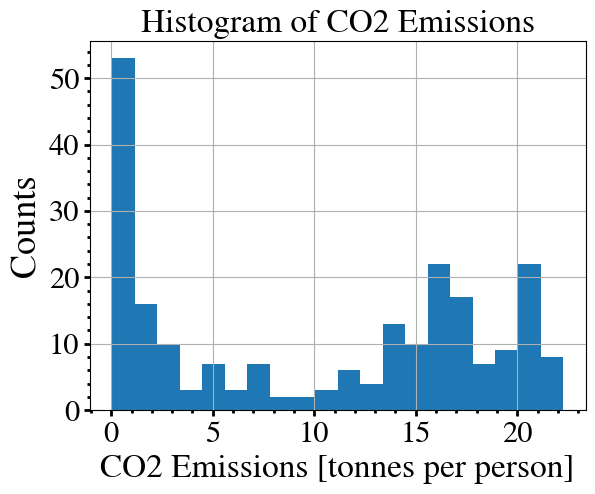

In [25]:
# plot histogram
df.emissions_total_per_capita.hist(bins=20)

plt.xlabel('CO2 Emissions [tonnes per person]', fontsize=24)
plt.ylabel('Counts', fontsize=26)
plt.title('Histogram of CO2 Emissions', fontsize=24)


plt.minorticks_on()
plt.tick_params(axis='x', labelsize=22, pad=4)
plt.tick_params(axis='y', labelsize=22)
plt.tick_params(which='both', width=2)
plt.tick_params(which='major', length=4)
plt.tick_params(which='minor', length=2)

plt.show()

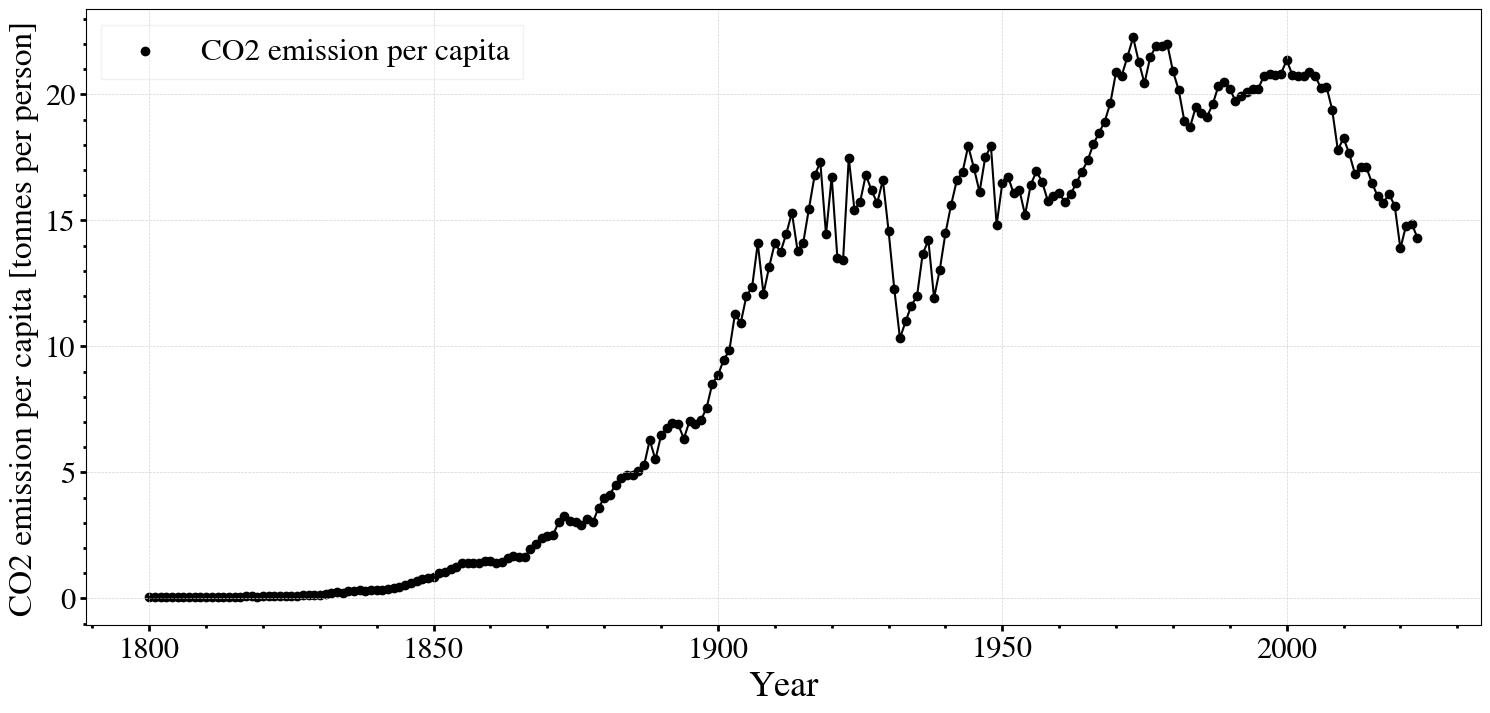

In [26]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(18, 8))


ax.plot(year, co2, color='k')
ax.scatter(year, co2, label='CO2 emission per capita', color='k', marker='o')

ax.set_xlabel('Year', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes per person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()


**There is presence of clear increasing trend but we do not see a seasonal trend at the moment.**

# Test for stationary

In [27]:
# Split the dataset into 2 segments
split = round(nrows / 2)
X1, X2 = co2[0:split], co2[split:]
mean1, mean2 = X1.mean(), X2.mean()
var1, var2 = X1.var(), X2.var()
print('mean1 = %f, mean2 = %f' % (mean1, mean2))
print('variance1 = %f, variance2 = %f' % (var1, var2))

mean1 = 2.962774, mean2 = 17.388041
variance1 = 14.477106, variance2 = 7.688963


**Since mean and variance changes drastically (from 3 to 17.4; and from 14.6 down to 7.8) it is evident that CO2_per_captia data is not stationary.**

**Below I will confirm it using ADFuller test.**

# Stationary Test using ADFuller test

In [28]:
rol_mean = df.emissions_total_per_capita.rolling(window = 20, center = False).mean()
rol_std = df.emissions_total_per_capita.rolling(window = 20, center = False).std()

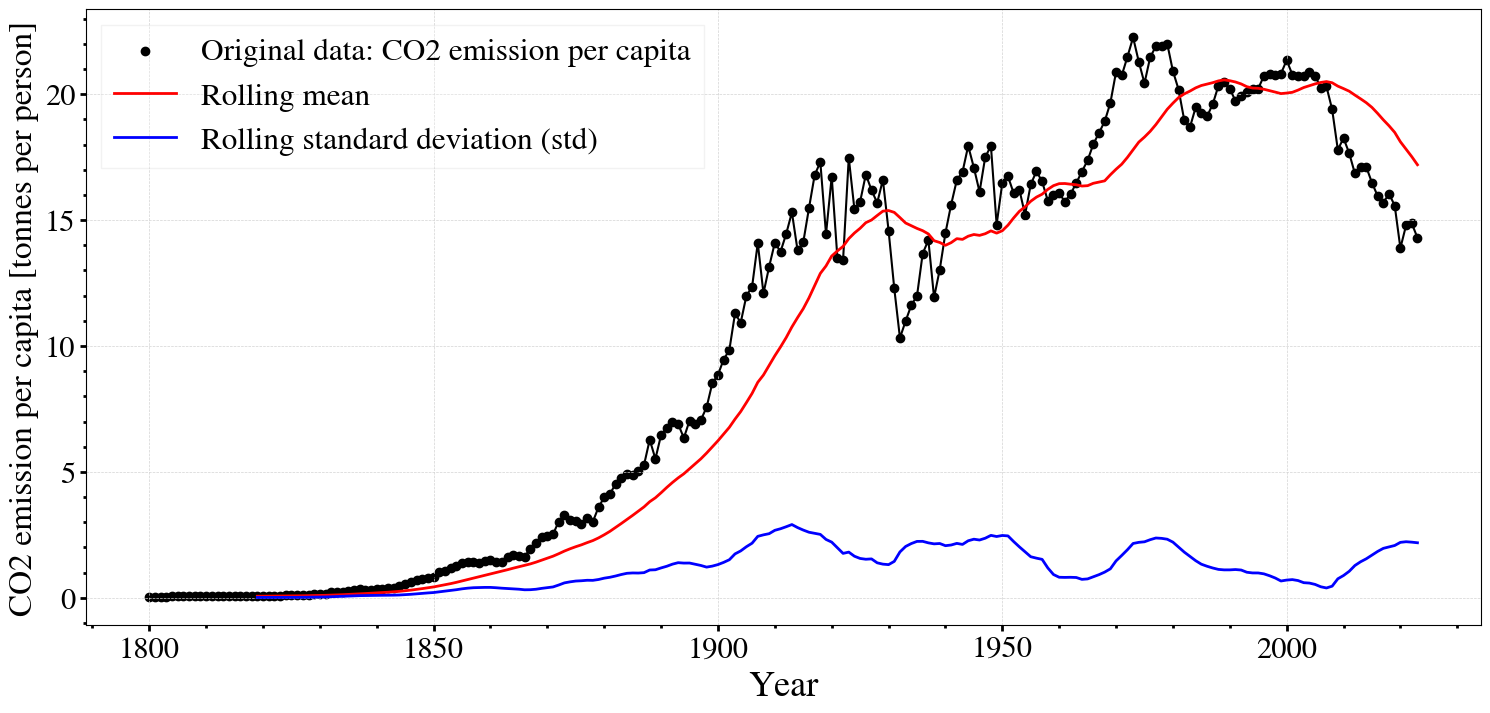

In [29]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(18, 8))


ax.plot(year, co2, color='k')
ax.scatter(year, co2, color='k', marker='o', label='Original data: CO2 emission per capita')
ax.plot(year, rol_mean, color = 'r', lw=2, label = 'Rolling mean')
ax.plot(year, rol_std, color ='b', lw=2, label = 'Rolling standard deviation (std)')

ax.set_xlabel('Year', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes per person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()


In [30]:
# Augmented Dickey-Fuller test
ADF_stationary_test(co2)


Test Statistic                  -1.290926
p-value                          0.633314
#Lags Used                      11.000000
Number of Observations Used    212.000000
Critical Value (1%)             -3.461578
Critical Value (5%)             -2.875272
Critical Value (10%)            -2.574089
dtype: float64

Failed to accept null hypothesis. Data is non-stationary


Here we can see that the *p-value (= 0.63)* is more than 0.05 this means our null hypothesis will be rejected and we will take this series as non-stationary.

# Differencing: 1st and 2nd orders

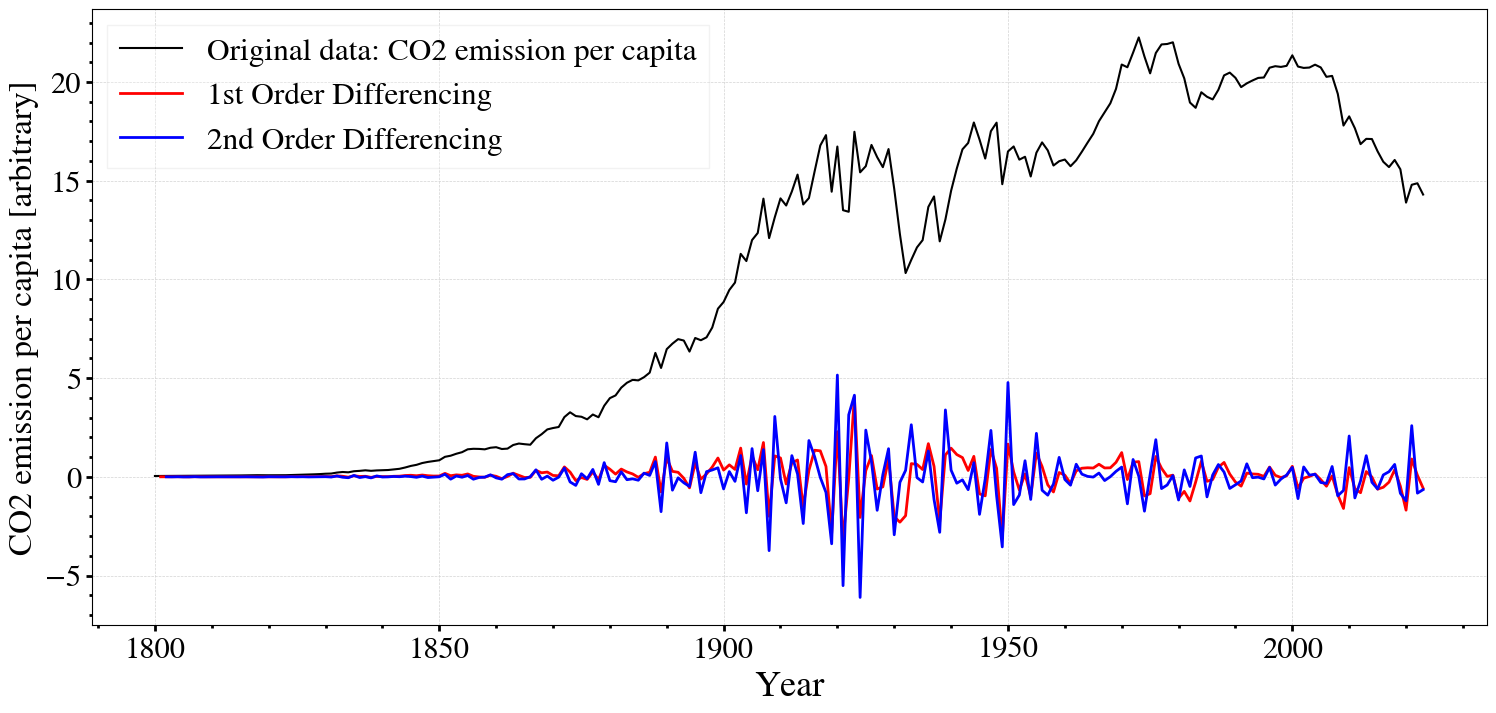

In [31]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(18, 8))


ax.plot(year, co2, color='k', label='Original data: CO2 emission per capita')
ax.plot(year[1:], np.diff(co2), color = 'r', lw=2, label = '1st Order Differencing')
ax.plot(year[2:], np.diff(np.diff(co2)), color ='b', lw=2, label = '2nd Order Differencing')

ax.set_xlabel('Year', fontsize=26)
ax.set_ylabel('CO2 emission per capita [arbitrary]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()


Here we can see how the time series has become stationary.

One thing which is noticeable here is in first-order differencing we have fewer noises in the data while 2nd order there is an increase in the noise.

So we can select 1st order differencing for our model.

Note: we can also verify this using an autocorrelation plot.

<ipython-input-32-0f656b1bff20>:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)
<ipython-input-32-0f656b1bff20>:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)
<ipython-input-32-0f656b1bff20>:52: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)


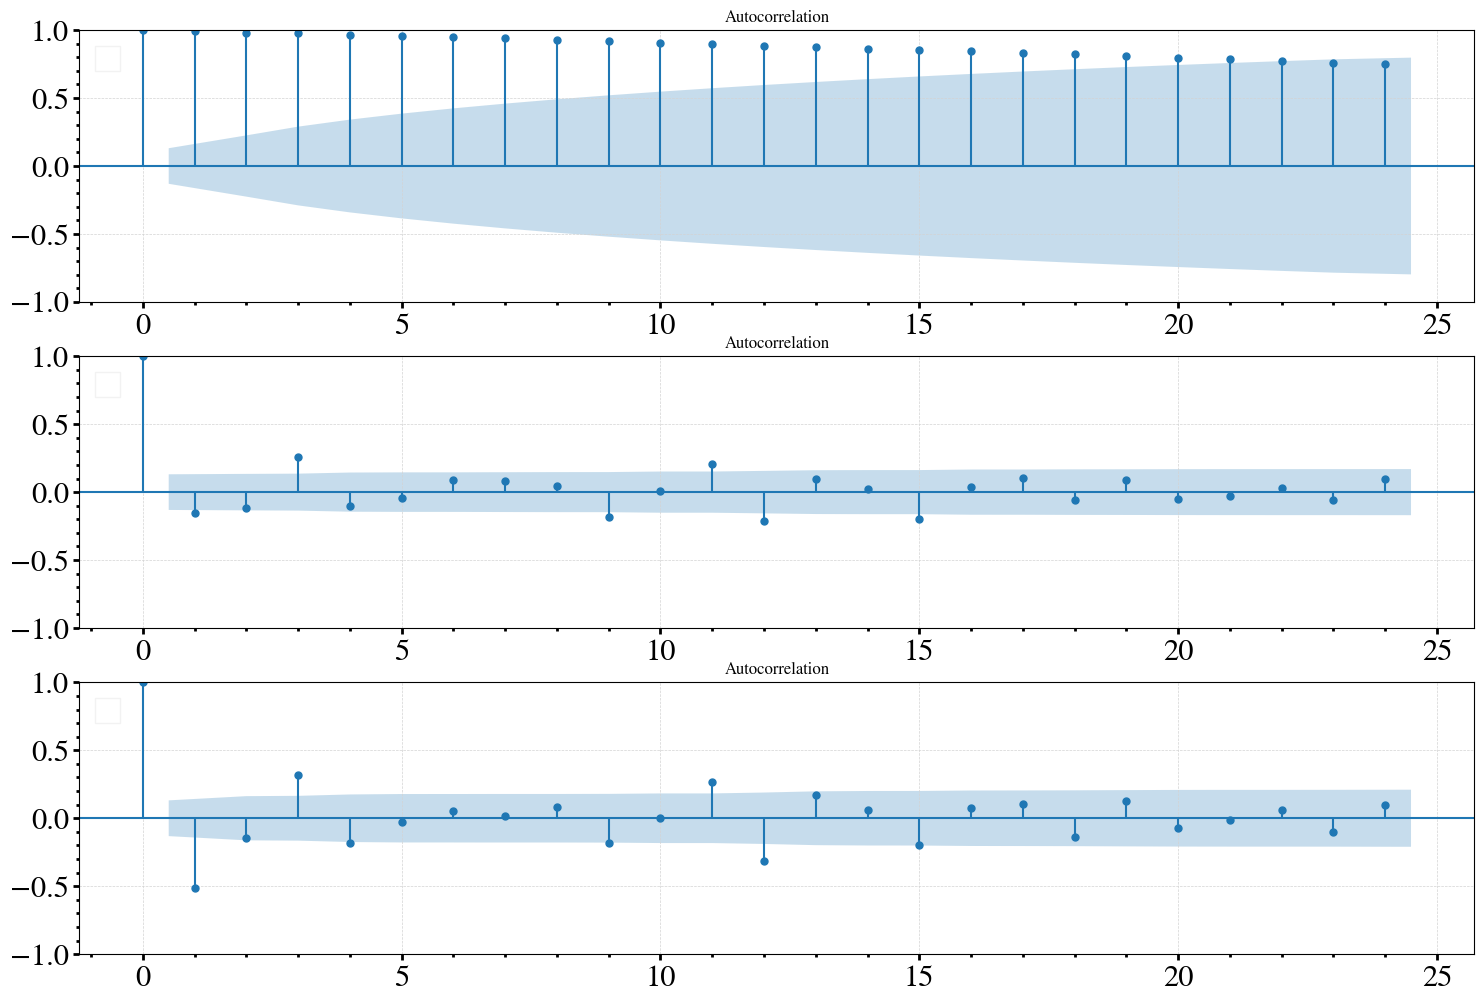

In [32]:
# Figure
fig, axes = plt.subplots(3, 1, figsize=(18, 12))


# ax
ax = axes[0]
plot_acf(co2, ax=ax)
ax.set_xlabel('', fontsize=26)
ax.set_ylabel('', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)


# ax
ax = axes[1]
plot_acf(np.diff(co2), ax=ax)
ax.set_xlabel('', fontsize=26)
ax.set_ylabel('', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

# ax
ax = axes[2]
plot_acf(np.diff(np.diff(co2)), ax=ax)
ax.set_xlabel('', fontsize=26)
ax.set_ylabel('', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()


# Inference framework: CO2 emission forecast

In [66]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [299]:
# Load real data
years = df.Year.values
data = df['emissions_total_per_capita'].values.reshape(-1, 1)

nsamples = len(xtime)
print('nsamples: ', nsamples)

nsamples:  224


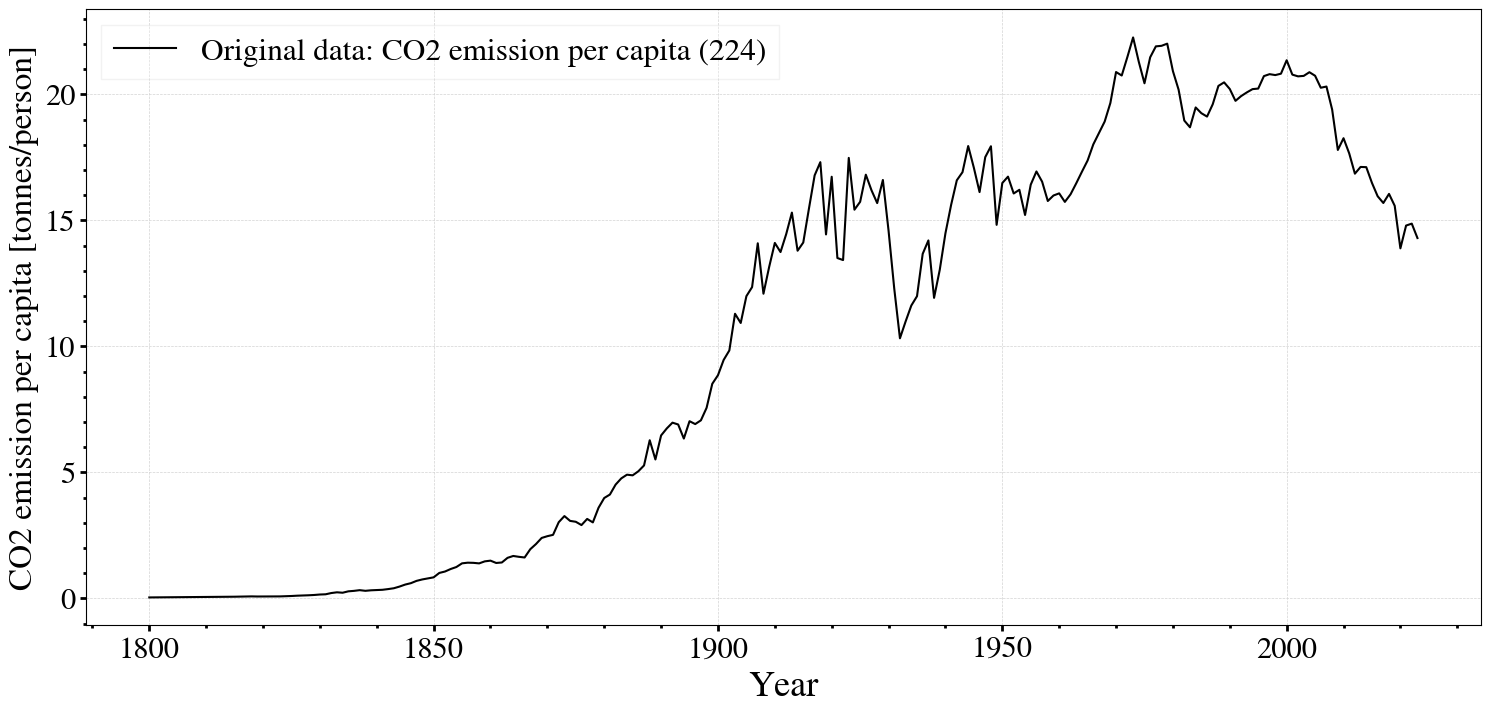

In [300]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(18, 8))


ax.plot(years, data, color='k', label=f'Original data: CO2 emission per capita ({nsamples})')

ax.set_xlabel('Year', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes/person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()

In [196]:
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)


# Create Dataset and DataLoader
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]




# 2. Model Setup (TransAm Transformer)
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:x.size(0), :]
        return self.dropout(x)




# Forecast model
class TransForecast(nn.Module):
    def __init__(self, feature_size=128, num_layers=1, dropout=0.1, num_heads=10, window_size=24):
        super(TransForecast, self).__init__()
        self.model_type = 'Transformer'
        self.window_size = window_size # add window_size to the class.
        self.src_mask = None
        self.pos_encoder = PositionalEncoding(feature_size)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=num_heads, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(feature_size, 1)
        self.init_weights()
        self.feature_size = feature_size

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        if self.src_mask is None or self.src_mask.size(0) != self.window_size: # use window_size here.
            device = src.device
            mask = self._generate_square_subsequent_mask(self.window_size).to(device) # use window_size here.
            self.src_mask = mask

        src = src.permute(1, 0, 2)  # (seq_len, batch, feature)
        src = self.pos_encoder(src * np.sqrt(self.feature_size))
        output = self.transformer_encoder(src, self.src_mask)
        output = self.decoder(output)
        output = output[-1]  # take the last prediction.
        return output

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

In [215]:
window_size = 24
batch_size = 32
epochs = 300
learning_rate = 0.001
feature_size = 64  # Adjustable, make sure it is divisible by the number of heads.
num_layers = 1
dropout = 0.1
num_heads = 8  # for Trasnformer, and adjustable

In [216]:
X, y = create_sequences(data, window_size)

In [217]:
# Scaling
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X.reshape(-1, 1)).reshape(X.shape)
y_scaled = scaler.transform(y)

In [218]:
# Training, validation and testing datasets
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.1, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.25, shuffle=False)

In [219]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [220]:
# Initiate Forecast model
model = TransForecast(feature_size=feature_size, num_layers=num_layers, dropout=dropout, num_heads=num_heads).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [198]:
# Device for training the Inference framewor: CPU or GPU(cuda)?
device

device(type='cuda')

In [255]:
# 3. Training
train_losses = []
val_losses = []
for epoch in range(epochs):
    model.train()
    total_train_loss = 0.
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs).squeeze()
        loss = criterion(outputs, targets.squeeze())
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    # End - for
    train_loss = total_train_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_loader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs).squeeze()
            val_loss += criterion(outputs, targets.squeeze()).item()
    # print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {val_loss / len(val_loader)}")
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

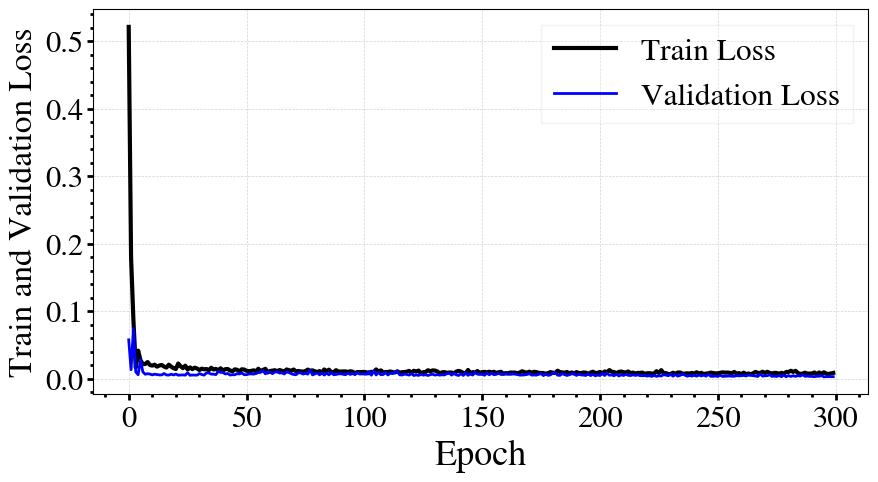

In [222]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(10, 5))


ax.plot(train_losses, color='k', lw=3, label=f'Train Loss')
ax.plot(val_losses, color='b', lw=2, label=f'Validation Loss')

ax.set_xlabel('Epoch', fontsize=26)
ax.set_ylabel('Train and Validation Loss', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='upper right', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()

In [256]:
# 4. Forecast / Prediction
model.eval()
predictions = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs).squeeze()
        predictions.extend(outputs.tolist())

predictions = np.array(predictions).reshape(-1, 1)
predictions_original_scale = scaler.inverse_transform(predictions)
y_test_original_scale = scaler.inverse_transform(y_test)

# Print predicted vs real values
print("Predicted values:")
print(predictions_original_scale)
print("Real values:")
print(y_test_original_scale)

Predicted values:
[[15.26967338]
 [15.75113073]
 [14.92542382]
 [14.88736866]
 [15.00687034]]
Real values:
[[15.57815189]
 [13.8895873 ]
 [14.79360255]
 [14.87076157]
 [14.29902585]]


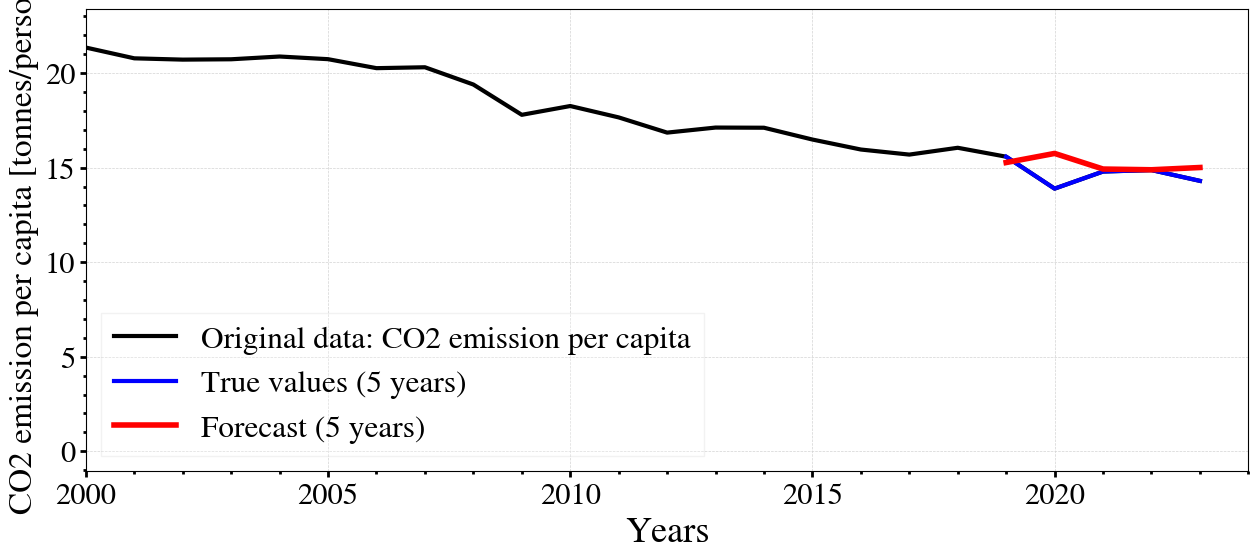

In [298]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(15, 6))


ax.plot(year, co2, color='k', lw=3, label='Original data: CO2 emission per capita')
# ax.plot(ft_years, ft_values, color = 'r', lw=2, label = 'Forecast for next 10 years')
ax.plot(year[-5:], y_test_original_scale, color='b', lw=3., label='True values (5 years)')
ax.plot(year[-5:], predictions_original_scale, color='r', lw=4., label='Forecast (5 years)')

ax.set_xlabel('Years', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes/person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.set_xlim(2000, 2024)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='lower left', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()

In [277]:
# 4. Forecasting (Multi-Step)
model.eval()
forecast_length = 10  # Number of years to forecast
forecasts = []
current_window = X_test[-1].unsqueeze(0).clone()  # Start with the last window from the test set
current_window = current_window.to(device)

with torch.no_grad():
    for _ in range(forecast_length):
        prediction = model(current_window).squeeze().item()
        forecasts.append(prediction)
        # Shift the window: remove the oldest value, append the prediction
        new_window = torch.cat(( current_window[0, 1:], torch.tensor([[prediction]]).to(device) ), dim=0).unsqueeze(0)
        current_window = new_window

# Inverse transform the forecasts
forecasts = np.array(forecasts).reshape(-1, 1)
forecasts_original_scale = scaler.inverse_transform(forecasts)

# Print the forecast values
print("Forecasted CO2 Emissions (Next 10 Years):")
print(forecasts_original_scale)

Forecasted CO2 Emissions (Next 10 Years):
[[15.00687034]
 [15.2139664 ]
 [15.37096843]
 [15.48415406]
 [15.51378253]
 [15.59714636]
 [15.91532801]
 [16.45142774]
 [16.83962346]
 [16.95343407]]


In [278]:
year_new = np.arange(2024, 2034)
year_new.shape

(10,)

In [276]:
new_years = np.insert(year, len(year), year[-1]+1)
new_years.shape

(225,)

In [272]:
y_test_original_scale_new = np.insert(y_test_original_scale, len(y_test_original_scale), forecasts_original_scale[0], axis=0)

(6, 1)

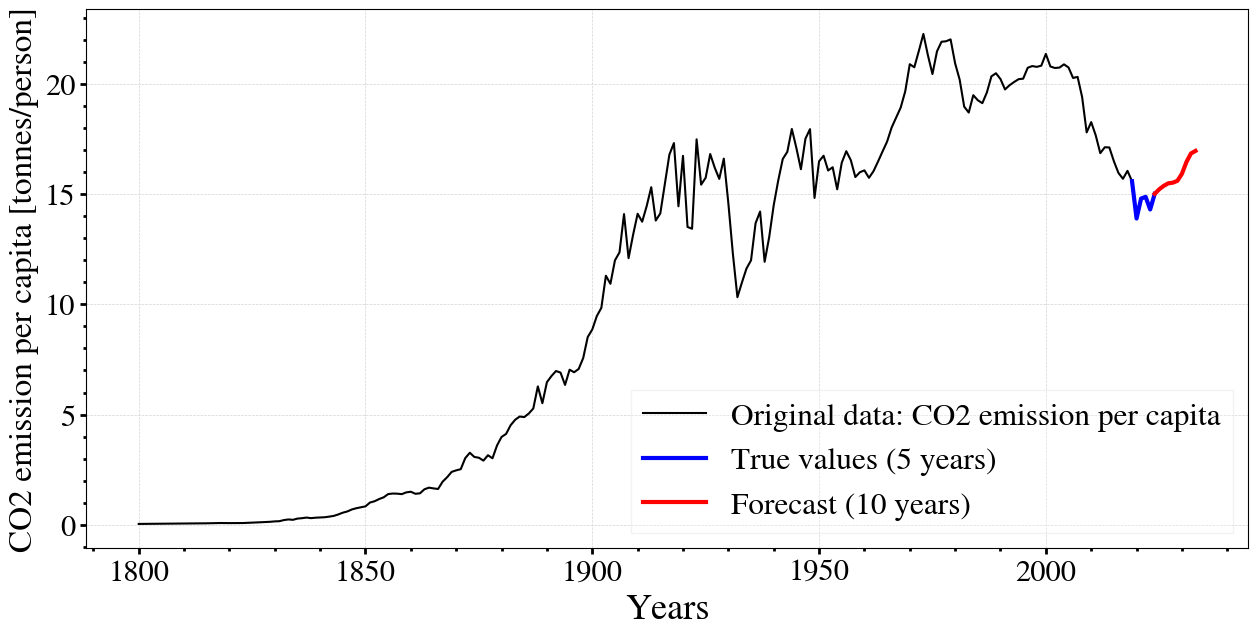

In [301]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(15, 7))


ax.plot(year, co2, color='k', label='Original data: CO2 emission per capita')
ax.plot(new_years[-6:], y_test_original_scale_new, color='b', lw=3., label='True values (5 years)')
ax.plot(year_new, forecasts_original_scale, 'r-', lw=3, label='Forecast (10 years)')

ax.set_xlabel('Years', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes/person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

# ax.set_xlim(2000, 2024)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='lower right', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()

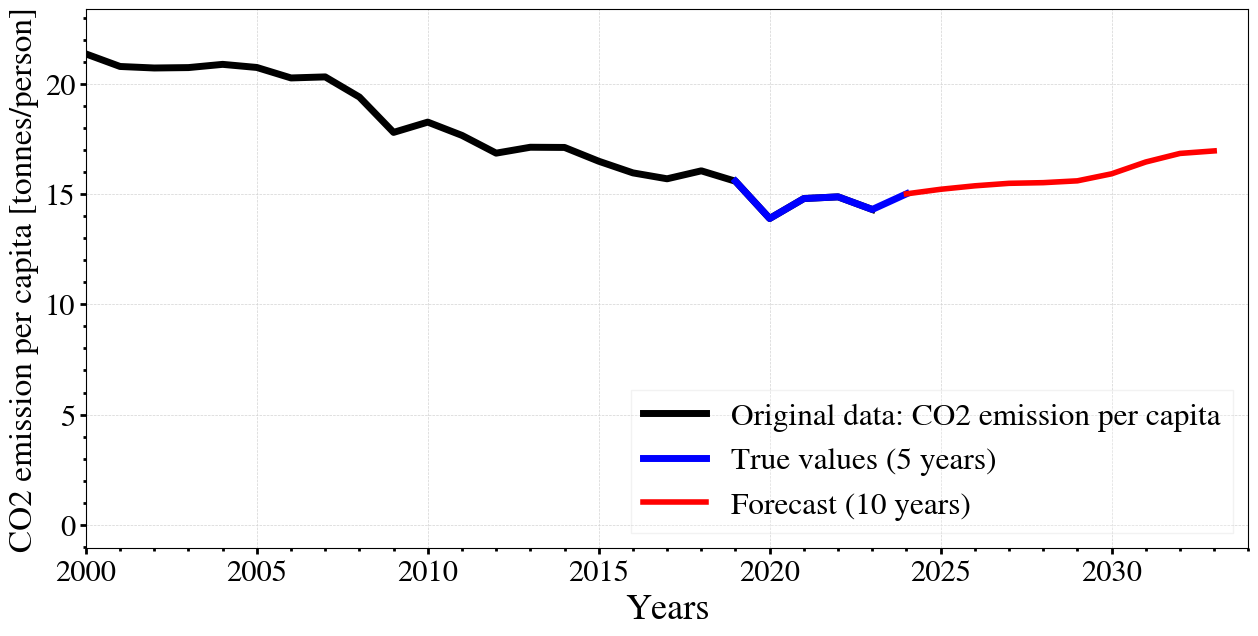

In [292]:
# Figure
fig, ax = plt.subplots(1, 1, figsize=(15, 7))


ax.plot(year, co2, color='k', lw=5, label='Original data: CO2 emission per capita')
ax.plot(new_years[-6:], y_test_original_scale_new, color='b', lw=5., label='True values (5 years)')
ax.plot(year_new, forecasts_original_scale, 'r-', lw=4, label='Forecast (10 years)')

ax.set_xlabel('Years', fontsize=26)
ax.set_ylabel('CO2 emission per capita [tonnes/person]', fontsize=24)

ax.minorticks_on()
ax.tick_params(axis='x', labelsize=22, pad=4)
ax.tick_params(axis='y', labelsize=22)
ax.tick_params(which='both', width=2)
ax.tick_params(which='major', length=4)
ax.tick_params(which='minor', length=2)

ax.set_xlim(2000, 2034)

ax.grid(True, linestyle='--', linewidth=0.5, color='lightgray', zorder=-10)
ax.legend(loc='lower right', fancybox=False, framealpha=0.25, labelcolor='k', fontsize=22.5)

plt.show()

# End